In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("processed/cleaned_data.csv")

In [3]:
df

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge,RiskScore
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,1.725883,0,0,0,1,0,0,XXXConfid,6.736513
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,2.592424,0,0,0,0,1,0,XXXConfid,15.805695
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,7.119548,0,1,0,1,0,0,XXXConfid,13.954458
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,1,6.481226,0,0,0,0,0,0,XXXConfid,13.991498
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0.014691,0,0,1,1,0,0,XXXConfid,11.374861
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,6895,61,0,0,1,39.121757,0,1.561126,4.049964,6.555306,...,0,4.492838,1,0,0,0,0,1,XXXConfid,12.188618
2145,6896,75,0,0,2,17.857903,0,18.767261,1.360667,2.904662,...,1,9.204952,0,0,0,0,0,1,XXXConfid,19.029947
2146,6897,77,0,0,1,15.476479,0,4.594670,9.886002,8.120025,...,0,5.036334,0,0,0,0,0,1,XXXConfid,19.935642
2147,6898,78,1,3,1,15.299911,0,8.674505,6.354282,1.263427,...,0,3.785399,0,0,0,0,1,1,XXXConfid,16.256222


In [41]:
#FEATURES = ['Age','Gender', 'BMI','EducationLevel', 'MemoryComplaints', 'BehavioralProblems', 'CholesterolHDL', 'Hypertension','CardiovascularDisease', 'CholesterolTriglycerides', 'DifficultyCompletingTasks']
#X = df[FEATURES]
def preprocess(df: pd.DataFrame):
    df = df.copy()
    X = df.drop(columns=['Diagnosis', 'DoctorInCharge'])
    y = df['Diagnosis']

    return X, y

In [7]:
!pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------- ----------------------------- 2.1/8.0 MB 11.8 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.0 MB 12.4 MB/s eta 0:00:01
   ----------------------------------- ---- 7.1/8.0 MB 11.5 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 11.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   -- ------------------------------------- 2.4/36.5 MB 12.2 MB/s eta 0:00:03
   ----- ---------------------------------- 4.7/36.5 MB 11.4 MB/s eta 0:00:03
   -------- ------------------------------- 7.3/36.5 MB 11.3 MB/s eta 0:00:03
   ---------- ----------------------------- 9.4/36.5 MB 11.3 MB/s eta 0:00:03
   ------------ --------------------------- 11.8/36.5 MB 11.2 MB/s eta 0:00:03
   ---------------- ----------------------- 14.7/36.5 MB 11.5 MB/s eta 0:00:02
   -----------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
!pip install joblib


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
!pip install xgboost catboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 6.3 MB/s eta 0:00:16
    --------------------------------------- 2.4/101.7 MB 6.1 MB/s eta 0:00:17
   - -------------------------------------- 3.9/101.7 MB 6.2 MB/s eta 0:00:16
   -- ------------------------------------- 6.0/101.7 MB 7.4 MB/s eta 0:00:13
   --- ------------------------------------ 8.1/101.7 MB 7.7 MB/s eta 0:00:13
   ---- ----------------------------------- 10.5/101.7 MB 8.4 MB/s eta 0:00:11
   ----- ---------------------------------- 13.4/101.7 MB 9.0 MB/s eta 0:00:10
   ------ --------------------------------- 15.7/101.7 MB 9.3 MB/s eta 0:00:10
   ------- -------------------------------- 17.8/101.7 MB 9.5 MB/s eta 0:00:09
   ------- -------------------------------- 20.2/101.7 MB 9.7 MB/s eta 0:00:09
   -------- ------------------------------- 22.5/101.7 MB 9.8 MB/s eta 0:00:09
   --------- ------------------------------ 24.9/101.7 MB 9.9 MB/


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import joblib

# Preprocess
X, y = preprocess(df)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
models = {
    "random_forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "xgboost": XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
    "catboost": CatBoostClassifier(verbose=0)
}

best_model = None
best_score = 0
best_name = ""

# Train & evaluate
for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    score = accuracy_score(y_test, preds)
    print(f"{name} accuracy: {score:.4f}")

    if score > best_score:
        best_score = score
        best_model = model
        best_name = name

# Save best model
joblib.dump(best_model, "model.pkl")

print(f"\nBest model: {best_name} ({best_score:.4f})")
print("Model saved to model.pkl")


Training random_forest...
random_forest accuracy: 0.9302

Training xgboost...
xgboost accuracy: 0.9651

Training catboost...


C:\Users\thaop\PycharmProjects\DataETL\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:07:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


catboost accuracy: 0.9651

Best model: xgboost (0.9651)
Model saved to model.pkl


In [31]:
importances = best_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\nFeature Importance:")
print(feature_importance_df)


Feature Importance:
                     feature  importance
2                        BMI    0.212448
8   CholesterolTriglycerides    0.211574
5             CholesterolHDL    0.202696
0                        Age    0.153200
3           MemoryComplaints    0.091096
4         BehavioralProblems    0.046395
1                     Gender    0.028414
9  DifficultyCompletingTasks    0.020326
6               Hypertension    0.017662
7      CardiovascularDisease    0.016188


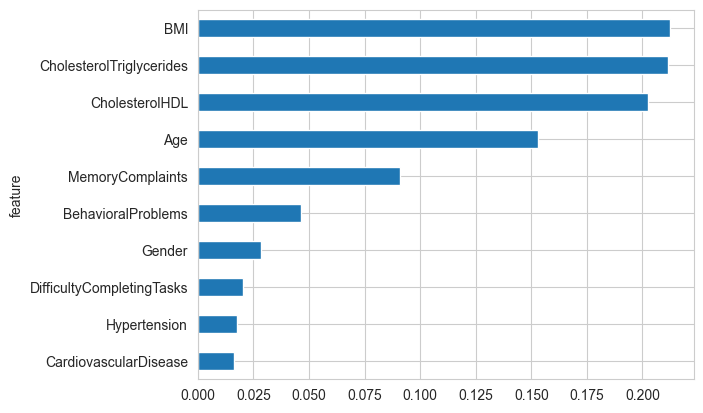

In [32]:
import matplotlib.pyplot as plt

feature_importance_df.plot(
    kind='barh',
    x='feature',
    y='importance',
    legend=False
)
plt.gca().invert_yaxis()
plt.show()

In [35]:
df.skew(numeric_only=True).sort_values(ascending=False)

HeadInjury                   2.812844
CardiovascularDisease        2.026465
Hypertension                 1.973834
PersonalityChanges           1.953350
Diabetes                     1.953350
BehavioralProblems           1.888867
Disorientation               1.874418
DifficultyCompletingTasks    1.869636
Depression                   1.496689
Confusion                    1.460887
MemoryComplaints             1.439838
Ethnicity                    1.230215
FamilyHistoryAlzheimers      1.141945
Smoking                      0.934260
Forgetfulness                0.865515
Diagnosis                    0.612627
EducationLevel               0.209118
Age                          0.045964
PhysicalActivity             0.044973
CholesterolHDL               0.042206
RiskScore                    0.040919
CholesterolLDL               0.036233
MMSE                         0.032382
AlcoholConsumption           0.018415
SystolicBP                   0.009971
PatientID                    0.000000
DietQuality 

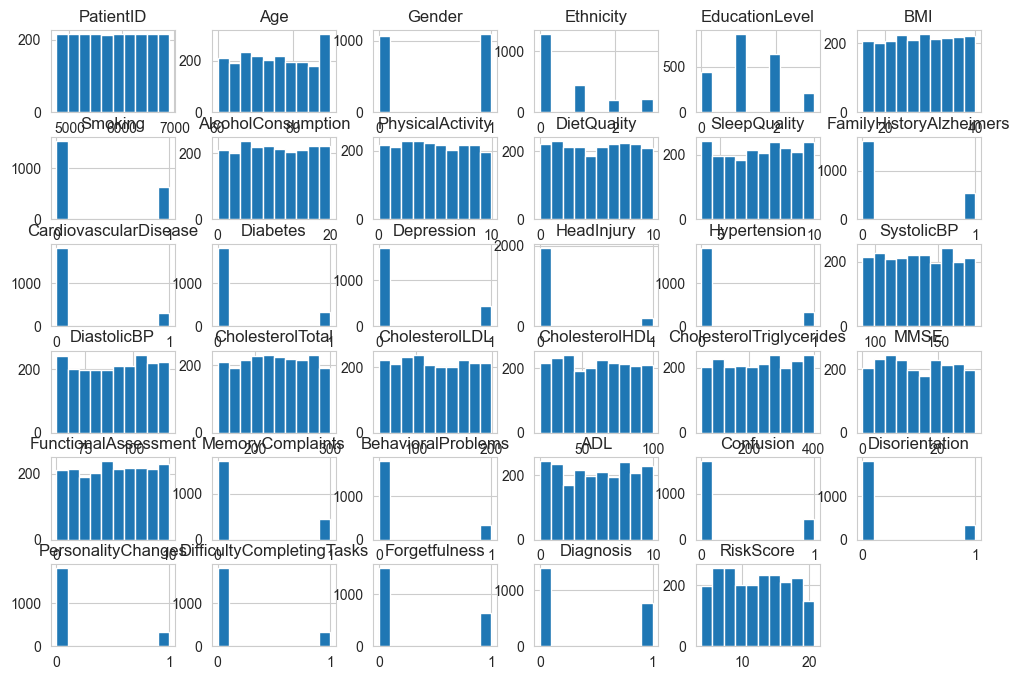

In [36]:
import matplotlib.pyplot as plt

df.hist(figsize=(12, 8))
plt.show()